# Fashion-MNIST Dataset Exploration

This notebook provides an initial exploration of the Fashion-MNIST dataset used for the classification experiments.

It loads the training and test sets, verifies the dataset dimensions and class distribution, and visualises representative samples from the training data.

### Dataset Overview

* **Training samples:** 60,000
* **Test samples:** 10,000
* **Image size:** 28 × 28 pixels
* **Channels:** 1 (grayscale)
* **Number of classes:** 10
* **Training samples per class:** 6,000

The dataset is balanced across all ten classes.


In [5]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [6]:
# Class names for Fashion-MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [7]:
# Load Fashion-MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.FashionMNIST(
    root='./data', 
    train=True,
    download=True, 
    transform=transform
)

testset = torchvision.datasets.FashionMNIST(
    root='./data', 
    train=False,
    download=True, 
    transform=transform
)

print(f"Training samples: {len(trainset)}")
print(f"Test samples: {len(testset)}")
print(f"Image shape: {trainset[0][0].shape}")

Training samples: 60000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])


In [8]:
def show_images(dataset, num_samples=10):
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    axes = axes.flatten()
    
    for i in range(num_samples):
        img, label = dataset[i]
        img = img.squeeze().numpy()
        
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f'{class_names[label]}')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

Sample images from training set:


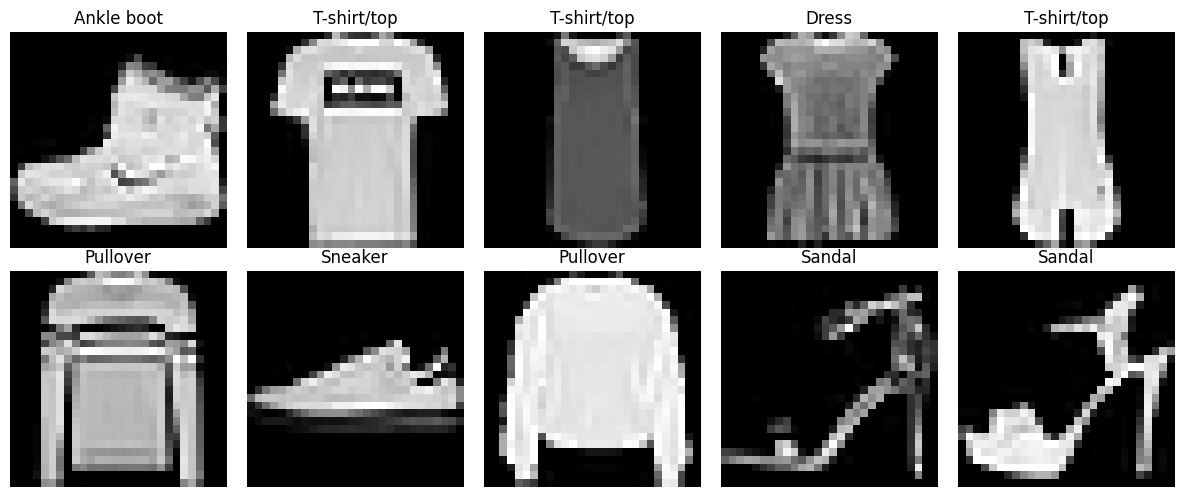

In [9]:
print("Sample images from training set:")
show_images(trainset, 10)

In [10]:
def check_class_distribution(dataset):
    labels = [label for _, label in dataset]
    unique, counts = np.unique(labels, return_counts=True)
    
    plt.figure(figsize=(10, 5))
    plt.bar(range(len(class_names)), counts)
    plt.xticks(range(len(class_names)), class_names, rotation=45)
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.title('Class Distribution in Training Set')
    plt.tight_layout()
    plt.show()
    
    for name, count in zip(class_names, counts):
        print(f"{name}: {count}")

Class distribution:


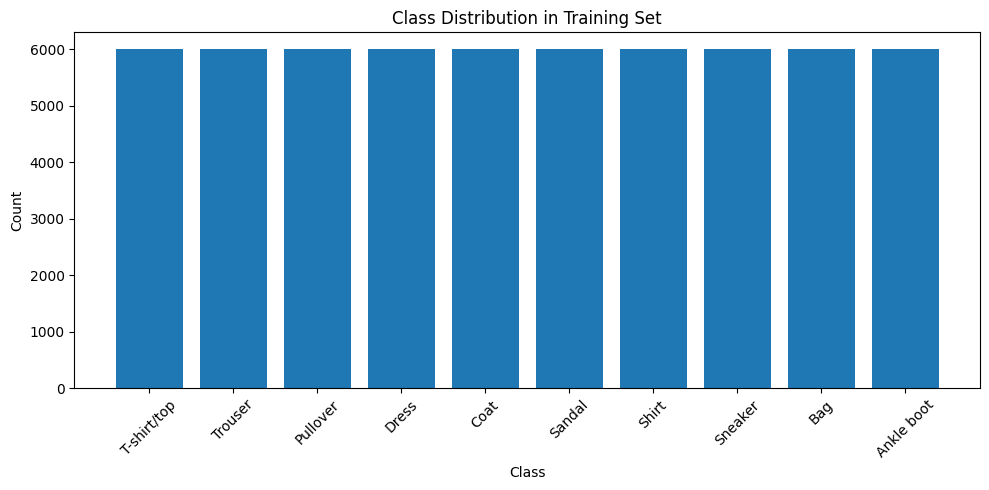

T-shirt/top: 6000
Trouser: 6000
Pullover: 6000
Dress: 6000
Coat: 6000
Sandal: 6000
Shirt: 6000
Sneaker: 6000
Bag: 6000
Ankle boot: 6000


In [11]:
print("Class distribution:")
check_class_distribution(trainset)